In [1]:
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
nltk.download('book')
from nltk.book import *

[nltk_data] Downloading collection 'book'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package brown to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/brown.zip.
[nltk_data]    | Downloading package chat80 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/chat80.zip.
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package conll2000 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/conll2000.zip.
[nltk_data]    | Downloading package conll2002 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/conll2002.zip.
[nltk_data]    | Downloading package dependency_treebank to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/dependency_treebank.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


# AGRUPACIÓN CON BI-GRAMAS

In [2]:
md_bigramas = list(bigrams(text1))
md_bigramas[:10]

[('[', 'Moby'),
 ('Moby', 'Dick'),
 ('Dick', 'by'),
 ('by', 'Herman'),
 ('Herman', 'Melville'),
 ('Melville', '1851'),
 ('1851', ']'),
 (']', 'ETYMOLOGY'),
 ('ETYMOLOGY', '.'),
 ('.', '(')]

In [3]:
fdist = FreqDist(md_bigramas)
fdist.most_common(10)

[((',', 'and'), 2607),
 (('of', 'the'), 1847),
 (("'", 's'), 1737),
 (('in', 'the'), 1120),
 ((',', 'the'), 908),
 ((';', 'and'), 853),
 (('to', 'the'), 712),
 (('.', 'But'), 596),
 ((',', 'that'), 584),
 (('.', '"'), 557)]

<Axes: xlabel='Samples', ylabel='Counts'>

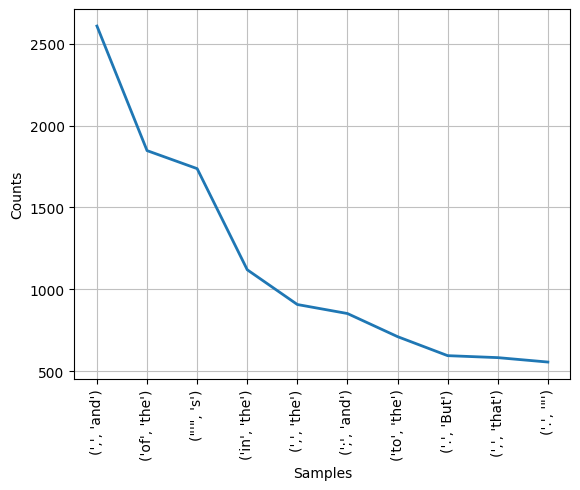

In [4]:
fdist.plot(10)

# FILTRADO PARA BIGRAMAS

<Axes: xlabel='Samples', ylabel='Counts'>

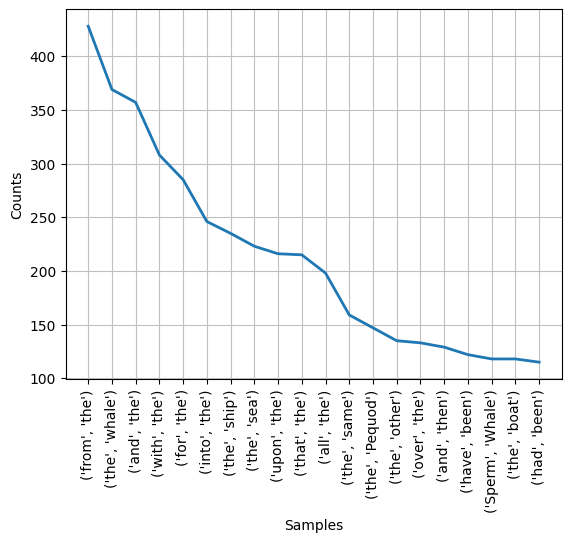

In [5]:
threshold = 2
filtered_bigrams = [bigram for bigram in md_bigramas if len(bigram[0])>threshold and len(bigram[1])>threshold]
filtered_dist = FreqDist(filtered_bigrams)
filtered_dist.plot(20)

# FILTRADO CON STOPWORDS

In [6]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
stop_words = set(stopwords.words('english'))
words = [word.lower() for word in text1 if word.isalpha()]
filtered_words = [word for word in words if word not in stop_words]
print(filtered_words[:10])

['moby', 'dick', 'herman', 'melville', 'etymology', 'supplied', 'late', 'consumptive', 'usher', 'grammar']


In [8]:
md_bigramas = list(bigrams(filtered_words))
md_bigramas[:10]

[('moby', 'dick'),
 ('dick', 'herman'),
 ('herman', 'melville'),
 ('melville', 'etymology'),
 ('etymology', 'supplied'),
 ('supplied', 'late'),
 ('late', 'consumptive'),
 ('consumptive', 'usher'),
 ('usher', 'grammar'),
 ('grammar', 'school')]

# N-GRAMAS (EJEMPLO CON TRI-GRAMAS)

In [9]:
from nltk.util import ngrams
md_trigrams = list(ngrams(filtered_words,3))
md_trigrams[:10]

[('moby', 'dick', 'herman'),
 ('dick', 'herman', 'melville'),
 ('herman', 'melville', 'etymology'),
 ('melville', 'etymology', 'supplied'),
 ('etymology', 'supplied', 'late'),
 ('supplied', 'late', 'consumptive'),
 ('late', 'consumptive', 'usher'),
 ('consumptive', 'usher', 'grammar'),
 ('usher', 'grammar', 'school'),
 ('grammar', 'school', 'pale')]

<Axes: xlabel='Samples', ylabel='Counts'>

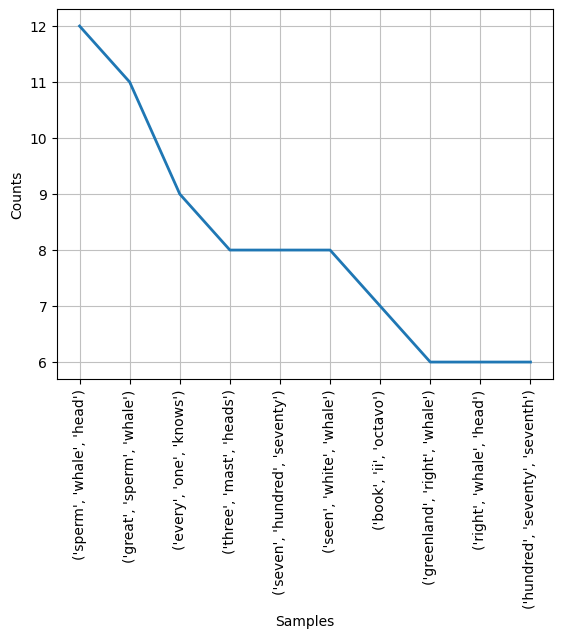

In [10]:
filtered_dist = FreqDist(md_trigrams)
filtered_dist.plot(10)